For now this is the simplest implementation possible; the model learns to predict going from t to t + delta t, with delta t currently being 5e-3. a simple shell then autoregressively predicts any multiple of delta t forward in time. dataset is from 0 to 1 seconds, so predictions further than this are less likely to work. For now no stabilization or rollout is implemented. For now I am just trying to understand if the new dataset shape works and how to have the model iteratively predict, as well as seeing how errors stack up.

In [1]:
from FNO1D_residual_def import *
import h5py
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
n_train = 80
n_test = 20
batch_size = 20
lr = 1e-3
epochs = 500
iterations = epochs * (n_train//batch_size)

modes = 16
width = 64

In [3]:
path = "/scratch/mnhagen/datasets/burgers/burgers1D_autoreg_Nx1024_nu0.01_samples100_dt0.001_store5.h5"
f = h5py.File(path, "r")
U = f["U"][:]  # [num_samples, T_sub, N_x]
X = f["X"][:]
Tlens = f["T_lengths"][:]
dt_eff = f.attrs["dt_eff"]

Y = X[None, :]

print(type(U.shape[0]))
print(dt_eff)

<class 'int'>
0.005


In [4]:
#make simple dataset: just pair of t and t + delta t

class Burgers1DStepDataset(torch.utils.data.Dataset):
    def __init__(self, h5_path, split = "train", split_ratio = (0.9, 0.1)):
        f = h5py.File(h5_path, "r")
        self.U = f["U"][:]
        self.X = f["X"][:]
        self.Tlens = f["T_lengths"][:]
        self.num_samples = self.U.shape[0]

        n_train = int(self.num_samples * split_ratio[0])
        if split == "train":
            self.idxs = range(0, n_train)
        else:
            self.idxs = range(n_train, self.num_samples)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, idx):
        j = self.idxs[idx]
        T = self.Tlens[j]
        t_idx = np.random.randint(0, T-1)
        u_in = self.U[j, t_idx, :]
        u_out = self.U[j, t_idx + 1, :]
        x = self.X
        return(
            torch.tensor(u_in[None, :], dtype = torch.float32),
            torch.tensor(u_out[None, :], dtype = torch.float32),
            torch.tensor(x[None, :], dtype = torch.float32)
        )

In [5]:
#Basic training loop

model_name = "autoreg_model_v0"
h5_path = "/scratch/mnhagen/datasets/burgers/burgers1D_autoreg_Nx1024_nu0.01_samples100_dt0.001_store5.h5"
model_dir = "/scratch/mnhagen/models/burgers"
batch_size = 16
modes = 16
width = 64
lr = 1e-3
val_patience = 25
epochs = 500

device = "cuda:0" if torch.cuda.is_available() else "cpu"
save_path = os.path.join(model_dir, model_name + ".pt")

#Datasets
train_ds = Burgers1DStepDataset(h5_path, "train")
val_ds = Burgers1DStepDataset(h5_path, "val")
train_loader = DataLoader(train_ds, batch_size = 16, shuffle = True)
val_loader = DataLoader(val_ds, batch_size = 16, shuffle = False)

#model
model = FNO1D_residual(modes = modes, width = width).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience = 10, factor = 0.5)

best_val_loss = float("inf")
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for u_in, u_target, x in train_loader:
        u_in, u_target, x = u_in.to(device), u_target.to(device), x.to(device)
        optimizer.zero_grad()
        u_pred = model(u_in, x)
        loss = F.mse_loss(u_pred, u_target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

#validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for u_in, u_target, x in val_loader:
            u_in, u_target, x = u_in.to(device), u_target.to(device), x.to(device)
            u_pred = model(u_in, x)
            val_loss += F.mse_loss(u_pred, u_target).item()
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | Train loss: {train_loss:.4e} | Val loss: {val_loss:.4e}")

#early stopping
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= val_patience:
        print("Early stop triggered.")
        break

Epoch 000 | Train loss: 1.9240e-03 | Val loss: 1.1683e-03
Epoch 001 | Train loss: 3.9253e-04 | Val loss: 4.0532e-04
Epoch 002 | Train loss: 3.0967e-04 | Val loss: 4.8887e-05
Epoch 003 | Train loss: 8.9596e-05 | Val loss: 1.2717e-04
Epoch 004 | Train loss: 6.5868e-05 | Val loss: 3.0147e-05
Epoch 005 | Train loss: 6.2229e-05 | Val loss: 1.5103e-05
Epoch 006 | Train loss: 2.3166e-05 | Val loss: 7.1748e-05
Epoch 007 | Train loss: 3.4144e-05 | Val loss: 9.6746e-05
Epoch 008 | Train loss: 2.6450e-05 | Val loss: 1.1987e-04
Epoch 009 | Train loss: 2.4048e-05 | Val loss: 4.4133e-05
Epoch 010 | Train loss: 2.8703e-05 | Val loss: 1.4128e-05
Epoch 011 | Train loss: 2.6235e-05 | Val loss: 4.2589e-05
Epoch 012 | Train loss: 1.9927e-05 | Val loss: 2.4100e-05
Epoch 013 | Train loss: 5.3272e-05 | Val loss: 4.1476e-06
Epoch 014 | Train loss: 2.7212e-05 | Val loss: 1.4002e-05
Epoch 015 | Train loss: 7.3807e-06 | Val loss: 6.8401e-06
Epoch 016 | Train loss: 1.6122e-05 | Val loss: 8.3295e-06
Epoch 017 | Tr

In [6]:
#Autoregressive prediction function

h5_path = "/scratch/mnhagen/datasets/burgers/burgers1D_autoreg_Nx1024_nu0.01_samples100_dt0.001_store5.h5"

def plot_auto_fno(model, h5_path, sample_idx = 0, t_final = 1.0,
        model_name = "FNO1D_residual", device = "cuda:0"):
    """
    Load one trajectory from dataset, roll out model and plot initial condition, ground truth and model prediction
    """
    device = torch.device(device if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    #Load dataset
    with h5py.File(h5_path, "r") as f:
        U = f["U"][:]
        X = f["X"][:]
        dt_eff = f.attrs.get("dt_eff", 1.0) if "attrs" in dir(f) else 1.0

    U_traj = U[sample_idx]
    num_steps = round(t_final/dt_eff)
    ratio = t_final / dt_eff
    nearest_int = round(ratio)
    if abs(ratio - nearest_int) > 1e-9:
        print(f"Final time rounded to nearest multiple of time interval {dt_eff}.")
    t_final_eff = num_steps * dt_eff

    #Prepare tensors
    x = torch.tensor(X[None, None, :], dtype = torch.float32).to(device)
    u0 = torch.tensor(U_traj[0][None, None, :], dtype = torch.float32).to(device)

    #Autoregressive rollout
    preds = [u0.detach().cpu().numpy().squeeze()]
    u = u0.clone()
    with torch.no_grad():
        for _ in range(num_steps):
            u = model(u, x)
            preds.append(u.detach().cpu().numpy().squeeze())
    preds = np.stack(preds, axis = 0)

    #Ground truth
    gt_final = U_traj[num_steps]

    #Plot
    fig, ax = plt.subplots(1, 3, figsize = (16,5))
    a = X

    fig.suptitle(f"{model_name} prediction after {t_final_eff} seconds - sample {sample_idx}")

    ax[0].set_title("Initial condition")
    ax[0].set_ylim(-1, 1)
    ax[0].plot(a, U_traj[0], color="C0")

    ax[1].set_title(f"Ground truth (t = {num_steps * dt_eff:.3f})")
    ax[1].set_ylim(-1, 1)
    ax[1].plot(a, gt_final, color="C1")

    ax[2].set_title(f"Model prediction (t = {num_steps * dt_eff:.3f})")
    ax[2].set_ylim(-1, 1)
    ax[2].plot(a, preds[-1], color="C2")

    plt.tight_layout()
    plt.show()

    return preds, gt_final
    


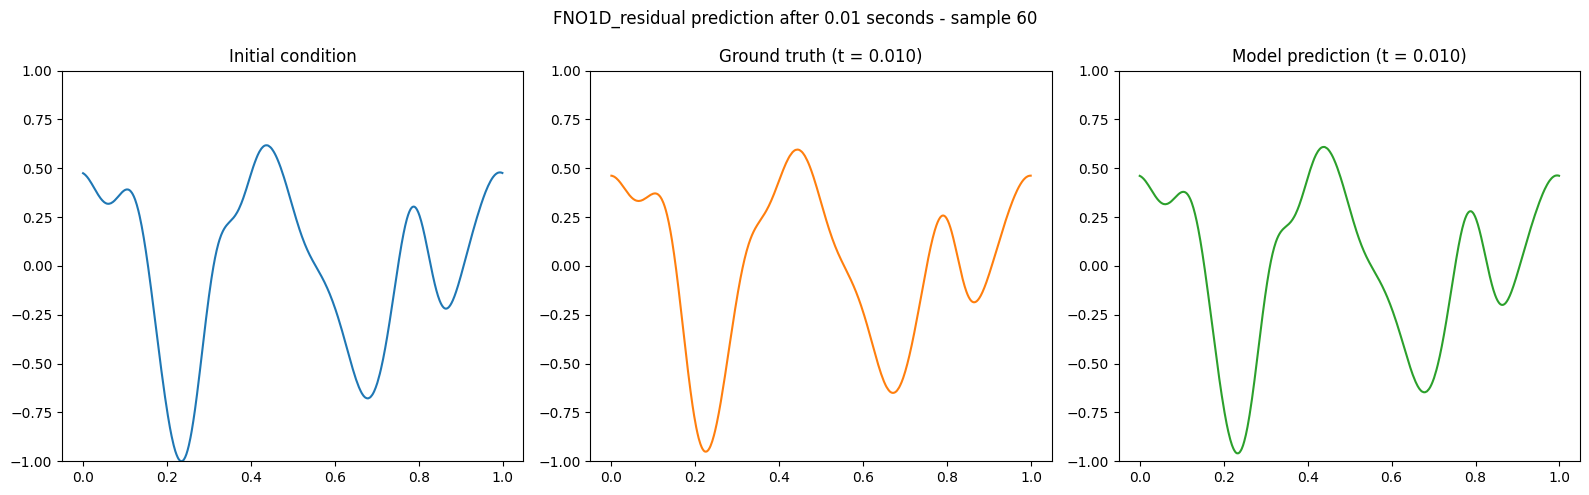

(array([[0.47460938, 0.47338867, 0.47192383, ..., 0.47753906, 0.47680664,
         0.47583008],
        [0.4677581 , 0.46667457, 0.46533987, ..., 0.47006243, 0.46945357,
         0.4686038 ],
        [0.46110892, 0.46014646, 0.45894095, ..., 0.46281782, 0.4623253 ,
         0.4615913 ]], shape=(3, 1024), dtype=float32),
 array([0.462 , 0.4617, 0.4612, ..., 0.462 , 0.4622, 0.4622],
       shape=(1024,), dtype=float16))

In [11]:
model = FNO1D_residual(modes=16, width=64)
model.load_state_dict(torch.load("/scratch/mnhagen/models/burgers/autoreg_model_v0.pt", map_location="cuda"))

t_final = 0.01
sample_idx = 60

plot_auto_fno(model, h5_path, t_final = t_final, sample_idx = sample_idx)